# 72 - Code Challenge: How Many Channels?

**Section:** CNNs | **Prereqs:** `CNNs/CodeChallenge_Softcode_Internal_Parameters.ipynb` | **Next:** `CNNs/CodeChallenge_How_Wide_FC_Layer.ipynb`

Sweep the first conv layer's channel count over 32, 64, 128, 256, 512 on EMNIST
and plot accuracy against it.

**What channels are.** Each output channel is one learned kernel - one feature
detector. More channels means more distinct patterns the layer can recognise at
once. Width here is capacity in the same sense that hidden units are capacity in
an FNN.

**Expect a plateau.** Accuracy climbs steeply from 32 to about 128 and then
flattens, while parameters and training time keep growing. Note the parameter
count does not grow linearly: the flatten into `Linear(2n*7*7, 512)` means
doubling `n` doubles that layer's parameters too, and it already dominates the
model.

**The practical rule:** pick the smallest width whose *validation* curve has
already flattened. Extra channels past that point buy nothing but compute and
overfitting risk.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import torchvision
from torchsummary import summary

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
# EMNIST letters, as in CNNs/EMNIST.ipynb.
train_data = torchvision.datasets.EMNIST(root='/',split='letters', train=True, download=True)
test_data = torchvision.datasets.EMNIST(root='/',split='letters', train=False, download=True)

100%|██████████| 562M/562M [00:04<00:00, 136MB/s]


In [3]:
data = train_data.data
labels = train_data.targets

val_data = test_data.data
val_labels = test_data.targets

In [4]:
# Drop the placeholder class; labels are shifted by -1 below.
categories = train_data.classes
categories = categories[1:]


In [5]:
# Plain TensorDatasets here - no transform pipeline, so no orientation fix and
# no augmentation. Fine for a sweep, where only the RELATIVE numbers matter,
# but it means these accuracies are not comparable to CNNs/EMNIST.ipynb's.
device = ('cuda' if torch.cuda.is_available() else 'cpu')

data_tensor = torch.tensor(data.numpy(), dtype=torch.float, device=device).view(data.shape[0],1,28,28)
label_tensor = torch.tensor(labels.numpy()-1, dtype=torch.long, device=device)

val_data_tensor = torch.tensor(val_data.numpy(), dtype=torch.float, device=device).view(val_data.shape[0],1,28,28)
val_label_tensor = torch.tensor(val_labels.numpy() -1, dtype=torch.long, device=device)

train_dataset = TensorDataset(data_tensor, label_tensor)
val_dataset = TensorDataset(val_data_tensor, val_label_tensor)

bs=128

train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset,batch_size=val_dataset.tensors[0].shape[0])

In [6]:
# The same architecture as CNNs/EMNIST.ipynb with the channel count as an
# argument: n and 2n.
# The Linear(2n*7*7, 512) input scales with n, so the parameter count grows fast
# - most of it in that one layer, not in the convolutions.
class EMNIST(nn.Module):
  def __init__(self, n=32) :
    super().__init__()
    '''
    Conv → BN → ReLU → Pool
    Raw features → normalize → activate → downsample
    (stable, standard, paper-recommended)
  '''

    self.layers = nn.Sequential(
        nn.Conv2d(1,n,kernel_size=3,padding=1,stride=1), # Ouput -> [64,28,28]
        nn.BatchNorm2d(n), # BatchNorm take input channels
        nn.LeakyReLU(),
        nn.AvgPool2d(2,2), # Output -> [64,14,14]

        nn.Conv2d(n,2*n, kernel_size=3, padding=1, stride=1), # Output -> [128,14,14]
        nn.BatchNorm2d(2*n),
        nn.LeakyReLU(),
        nn.AvgPool2d(2,2), # Output -> [128,7,7]

        nn.Flatten(),
        nn.Linear(2*n*7*7, 512),
        nn.ReLU(),
        nn.Dropout(p=0.4),
        nn.Linear(512,26)

    )

  def forward(self,x):
    return self.layers(x)

In [7]:
# The widest instance (n=512) to check it builds.
test_model = EMNIST(512)
test_model.to(device)

EMNIST(
  (layers): Sequential(
    (0): Conv2d(1, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (4): Conv2d(512, 1024, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.01)
    (7): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (8): Flatten(start_dim=1, end_dim=-1)
    (9): Linear(in_features=50176, out_features=512, bias=True)
    (10): ReLU()
    (11): Dropout(p=0.4, inplace=False)
    (12): Linear(in_features=512, out_features=26, bias=True)
  )
)

In [8]:
# The summary. Look at where the parameters actually are: the flatten->Linear
# boundary dominates, which is the argument for global average pooling.
summary(test_model, input_size=(1,28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 512, 28, 28]           5,120
       BatchNorm2d-2          [-1, 512, 28, 28]           1,024
         LeakyReLU-3          [-1, 512, 28, 28]               0
         AvgPool2d-4          [-1, 512, 14, 14]               0
            Conv2d-5         [-1, 1024, 14, 14]       4,719,616
       BatchNorm2d-6         [-1, 1024, 14, 14]           2,048
         LeakyReLU-7         [-1, 1024, 14, 14]               0
         AvgPool2d-8           [-1, 1024, 7, 7]               0
           Flatten-9                [-1, 50176]               0
           Linear-10                  [-1, 512]      25,690,624
             ReLU-11                  [-1, 512]               0
          Dropout-12                  [-1, 512]               0
           Linear-13                   [-1, 26]          13,338
Total params: 30,431,770
Trainable para

In [9]:
# Training function taking n. 10 epochs per run to keep the sweep affordable -
# enough to rank the widths, not enough for a final model.
def train_model(n):

  model = EMNIST(n).to(device)

  lossfunc = nn.CrossEntropyLoss()
  epochs = 10
  optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=0.05,
    betas=(0.9, 0.999)
)


  losses = []
  train_acc = []
  val_acc = []

  l1_lambda = 1e-4

  for epoch in range(epochs):

    model.train()

    batch_acc = []
    batch_loss = []

    for x,y in train_loader:

      yhat = model(x)

      loss = lossfunc(yhat,y)

      # Calculate L1 norm and normalize by the number of parameters
      l1_norm = sum(p.abs().sum() for p in model.parameters())
      num_parameters = sum(p.numel() for p in model.parameters())
      loss = loss + l1_lambda * (l1_norm / num_parameters)

      batch_loss.append(loss.item())

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      acc = 100 * torch.mean( (torch.argmax(yhat, dim=1) == y).float().detach().cpu())
      batch_acc.append(acc)

    losses.append(np.mean(batch_loss))
    train_acc.append(np.mean(batch_acc))

    # Now validation

    model.eval()
    with torch.no_grad():
      X,Y = next(iter(val_loader))
      X = X.to(device)
      Y = Y.to(device)
      val_acc.append( 100 * torch.mean( (torch.argmax(model(X), dim=1) == Y).float().detach().cpu()) )


    if epoch % 10 == 0 or epoch == epochs-1 :
      print(f'Epoch {epoch} | Number of channels : {n}| Loss : {losses[epoch]:.4f} | Train Acc {train_acc[epoch]} | Val Acc : {val_acc[epoch]}')

  return losses[-1], train_acc[-1], val_acc[-1]

In [15]:
# The sweep: 5 widths, 5 training runs.
no_of_channels = [32,64,128,256,512]

losses, train_acc, val_acc = [],[],[]

for i in range(len(no_of_channels)):
  loss, train, val = train_model(no_of_channels[i])

  losses.append(loss)
  train_acc.append(train)
  val_acc.append(val)
  print()


Epoch 0 | Number of channels : 32| Loss : 0.7552 | Train Acc 78.48236846923828 | Val Acc : 89.70673370361328
Epoch 9 | Number of channels : 32| Loss : 0.1648 | Train Acc 94.39102935791016 | Val Acc : 93.6346206665039

Epoch 0 | Number of channels : 64| Loss : 0.6249 | Train Acc 81.54566955566406 | Val Acc : 90.94711303710938
Epoch 9 | Number of channels : 64| Loss : 0.1491 | Train Acc 94.80288696289062 | Val Acc : 94.26922607421875

Epoch 0 | Number of channels : 128| Loss : 0.5504 | Train Acc 83.34855651855469 | Val Acc : 91.27404022216797
Epoch 9 | Number of channels : 128| Loss : 0.1446 | Train Acc 94.90625 | Val Acc : 94.4375

Epoch 0 | Number of channels : 256| Loss : 0.5070 | Train Acc 84.17708587646484 | Val Acc : 91.75961303710938
Epoch 9 | Number of channels : 256| Loss : 0.1462 | Train Acc 94.71554565429688 | Val Acc : 94.28365325927734

Epoch 0 | Number of channels : 512| Loss : 0.4881 | Train Acc 84.78205108642578 | Val Acc : 91.51923370361328
Epoch 9 | Number of channels :

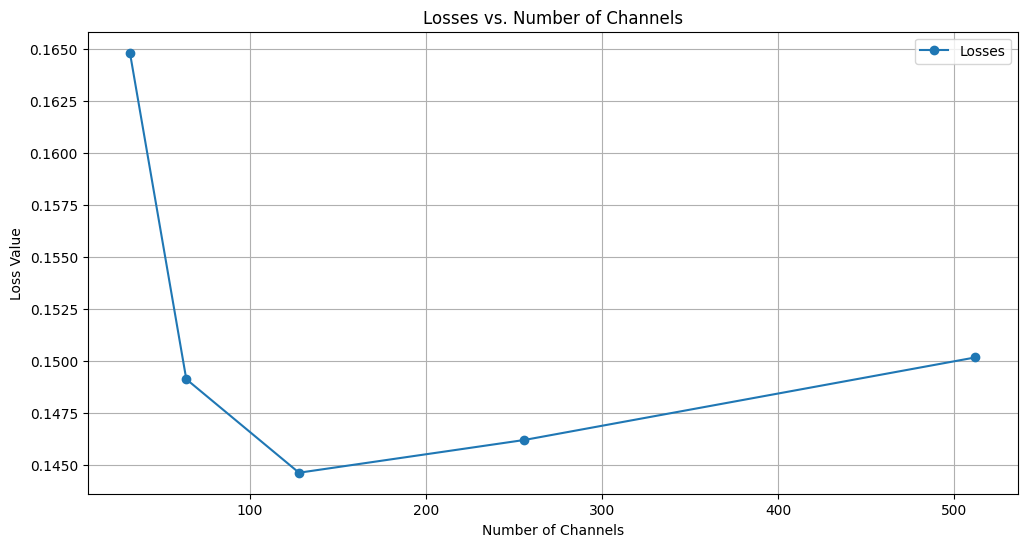

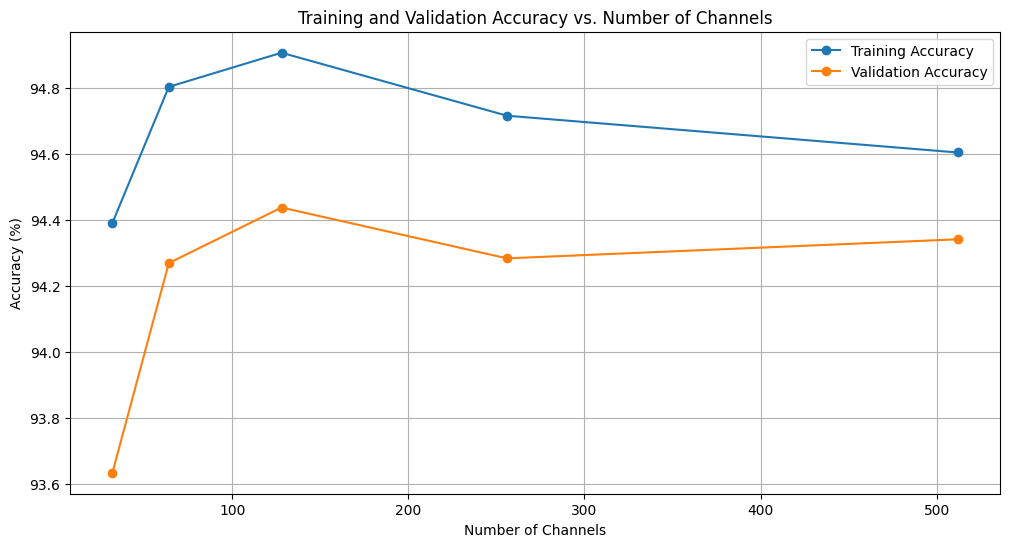

In [19]:
# Loss and accuracy vs channel count.
# Expect a steep climb then a plateau. Read the VALIDATION curve: the point where
# it flattens is the answer. Beyond it, extra channels only add parameters,
# training time and overfitting risk.
plt.figure(figsize=(12, 6))
plt.plot(no_of_channels, losses, label='Losses', marker='o')
plt.xlabel('Number of Channels')
plt.ylabel('Loss Value')
plt.title('Losses vs. Number of Channels')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(no_of_channels, train_acc, label='Training Accuracy', marker='o')
plt.plot(no_of_channels, val_acc, label='Validation Accuracy', marker='o')
plt.xlabel('Number of Channels')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy vs. Number of Channels')
plt.legend()
plt.grid(True)
plt.show()